In [20]:
import pandas as pd
import numpy as np

from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold, KFold

from scipy.stats import ks_2samp

from xgboost import XGBClassifier

import shap

import matplotlib.pyplot as plt 

In [21]:
df =  pd.read_csv("datasets/snythetic_risk_analysis_dataset.csv")

In [22]:
df.shape

(10000, 13)

In [23]:
df.columns

Index(['Customer_ID', 'County', 'Population_Density_Category', 'Annual_Income',
       'Monthly_Inhand_Salary', 'Outstanding_Debt', 'Num_of_Loan',
       'Total_EMI_per_month', 'Credit_Utilization_Ratio', 'Credit_History_Age',
       'Num_of_Delayed_Payment', 'Monthly_Balance', 'Default_Flag'],
      dtype='object')

In [24]:
df["emi_to_income_ratio"] = df["Total_EMI_per_month"] / df["Monthly_Inhand_Salary"]
df["debt_to_income_ratio"] = df["Outstanding_Debt"] / df["Annual_Income"]
df["savings_ratio"] = df["Monthly_Balance"] / df["Monthly_Inhand_Salary"]
df["Delinquency"] = df["Num_of_Delayed_Payment"] / df["Num_of_Loan"]

df["Repayment_Stress"] = df["emi_to_income_ratio"] * df["Delinquency"]
df["Risk_Index"] = (df["debt_to_income_ratio"] + df["Delinquency"]) / 2

In [25]:
df.shape

(10000, 19)

In [26]:
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.fillna(df.median(numeric_only=True), inplace=True)

In [28]:
df.shape

(10000, 19)

In [29]:
df.columns

Index(['Customer_ID', 'County', 'Population_Density_Category', 'Annual_Income',
       'Monthly_Inhand_Salary', 'Outstanding_Debt', 'Num_of_Loan',
       'Total_EMI_per_month', 'Credit_Utilization_Ratio', 'Credit_History_Age',
       'Num_of_Delayed_Payment', 'Monthly_Balance', 'Default_Flag',
       'emi_to_income_ratio', 'debt_to_income_ratio', 'savings_ratio',
       'Delinquency', 'Repayment_Stress', 'Risk_Index'],
      dtype='object')

In [30]:
X = df.drop(columns=["Default_Flag", 'Customer_ID', 'County', 'Population_Density_Category'], axis=1)

y = df["Default_Flag"]

In [31]:
X.columns

Index(['Annual_Income', 'Monthly_Inhand_Salary', 'Outstanding_Debt',
       'Num_of_Loan', 'Total_EMI_per_month', 'Credit_Utilization_Ratio',
       'Credit_History_Age', 'Num_of_Delayed_Payment', 'Monthly_Balance',
       'emi_to_income_ratio', 'debt_to_income_ratio', 'savings_ratio',
       'Delinquency', 'Repayment_Stress', 'Risk_Index'],
      dtype='object')

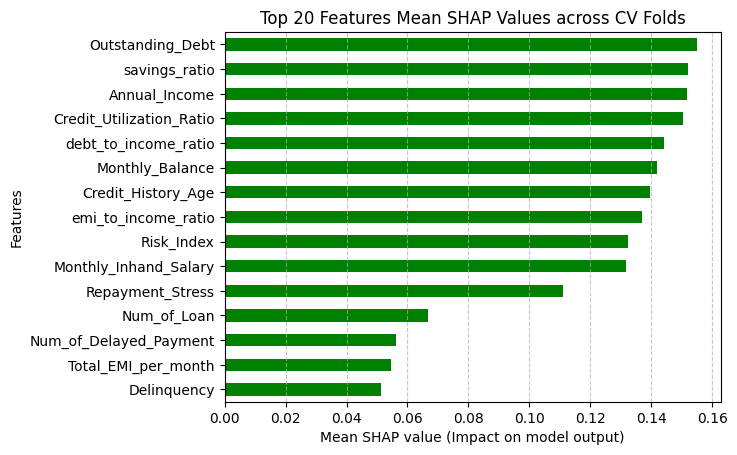

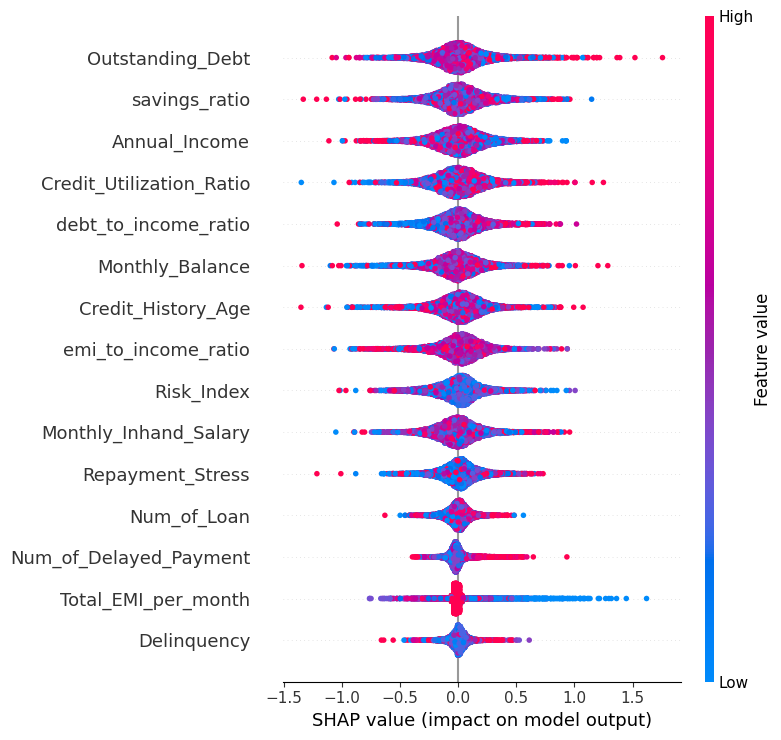

In [32]:
folds = KFold(n_splits=7, shuffle=True, random_state=42)
shap_values_list = []

for train_idx, val_idx in folds.split(X):

    xgb_m = XGBClassifier(enable_categorical=True, tree_method="hist").fit(X.iloc[train_idx], y.iloc[train_idx])

    explainer = shap.TreeExplainer(xgb_m)
    shap_fold = explainer.shap_values(X.iloc[val_idx])
    shap_values_list.append(shap_fold)

all_shap = np.vstack(shap_values_list)
mean_shap = np.abs(all_shap).mean(axis=0)

feature_importance = pd.Series(mean_shap, index=X.columns).sort_values(ascending=False)

#print("Top Features - Mean Absolute SHAP values:")
#print(feature_importance)

plt.Figure(figsize=(10, 6))
feature_importance.head(20).plot(kind="barh", color="green").invert_yaxis()
plt.title("Top 20 Features Mean SHAP Values across CV Folds")
plt.xlabel("Mean SHAP value (Impact on model output)")
plt.ylabel("Features")
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.show()

shap.summary_plot(all_shap, X.iloc[np.concatenate([v for _, v in folds.split(X)])])

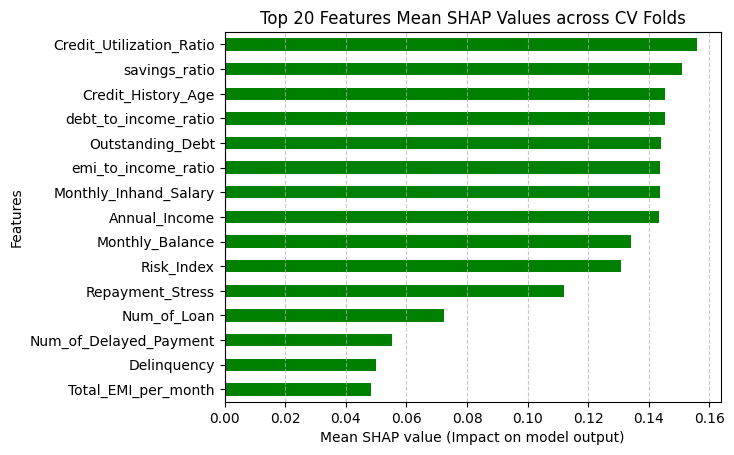

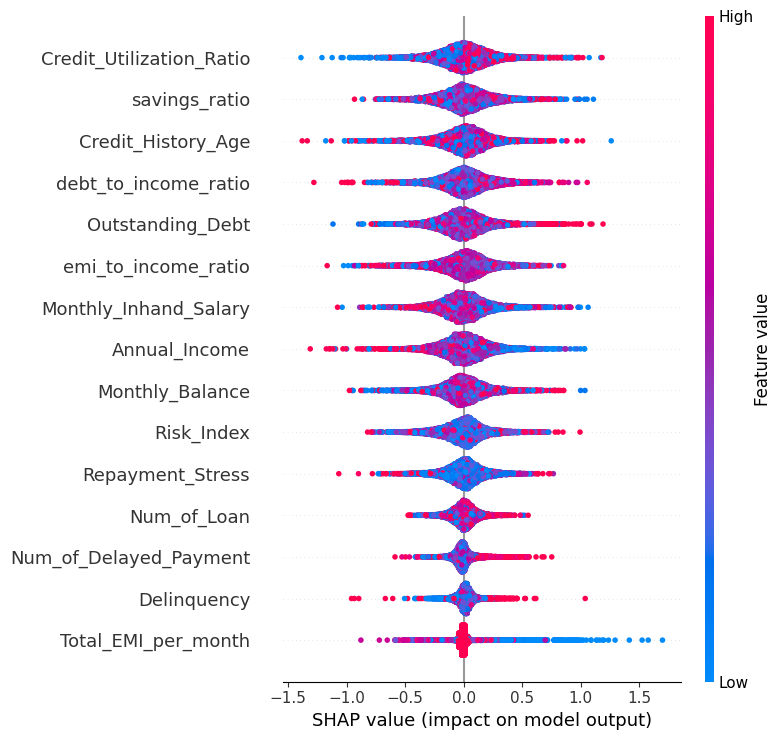

In [33]:
folds = StratifiedKFold(n_splits=7, shuffle=True, random_state=42)
shap_values_list = []

for train_idx, val_idx in folds.split(X,y):

    xgb_m = XGBClassifier(enable_categorical=True, tree_method="hist").fit(X.iloc[train_idx], y.iloc[train_idx])

    explainer = shap.TreeExplainer(xgb_m)
    shap_fold = explainer.shap_values(X.iloc[val_idx])
    shap_values_list.append(shap_fold)

all_shap = np.vstack(shap_values_list)
mean_shap = np.abs(all_shap).mean(axis=0)

feature_importance = pd.Series(mean_shap, index=X.columns).sort_values(ascending=False)

#print("Top Features - Mean Absolute SHAP values:")
#print(feature_importance)

plt.Figure(figsize=(10, 6))
feature_importance.head(20).plot(kind="barh", color="green").invert_yaxis()
plt.title("Top 20 Features Mean SHAP Values across CV Folds")
plt.xlabel("Mean SHAP value (Impact on model output)")
plt.ylabel("Features")
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.show()

shap.summary_plot(all_shap, X.iloc[np.concatenate([v for _, v in folds.split(X,y)])])

In [34]:
scale_pos_weight = len(y[y==0]) / len([y==1])

folds = KFold(n_splits=7, shuffle=True, random_state=42)

auc_scores = []
ks_scores = []

for train_idx, val_idx in folds.split(X):

    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    model = XGBClassifier(n_estimators=500,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.8,
    scale_pos_weight=scale_pos_weight,
    colsample_bytree=0.8,
    min_child_weight=5,
    gamma=0.1,
    reg_alpha=0.5,
    enable_categorical=True, 
    tree_method="hist",
    reg_lambda=1.5,
    random_state=42)
    
    model.fit(X_train, y_train)

    # Predict probabilities
    y_prob = model.predict_proba(X_val)[:,1]

    # AUC
    auc = roc_auc_score(y_val, y_prob)
    auc_scores.append(auc)

    # KS Statistic
    ks = ks_2samp(
        y_prob[y_val==0],
        y_prob[y_val==1]
    ).statistic
    ks_scores.append(ks)


print("AUC per fold:", auc_scores)
print("Mean AUC:", np.mean(auc_scores))

print("KS per fold:", ks_scores)
print("Mean KS:", np.mean(ks_scores))

AUC per fold: [0.500496200177864, 0.4746659931758339, 0.4864579443380354, 0.5154332864352225, 0.5043299524207548, 0.5181893867728651, 0.4927049543579044]
Mean AUC: 0.4988968168112114
KS per fold: [np.float64(0.06314374646293153), np.float64(0.06403234378866994), np.float64(0.04534028806733082), np.float64(0.05055375846270398), np.float64(0.0397833215456825), np.float64(0.0433693157533317), np.float64(0.04017435260264159)]
Mean KS: 0.04948530381189886


In [35]:
scale_pos_weight = len(y[y==0]) / len([y==1])

folds = StratifiedKFold(n_splits=7, shuffle=True, random_state=42)

auc_scores = []
ks_scores = []

for train_idx, val_idx in folds.split(X, y):

    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    model = XGBClassifier(n_estimators=500,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.8,
    scale_pos_weight=scale_pos_weight,
    colsample_bytree=0.8,
    min_child_weight=5,
    gamma=0.1,
    reg_alpha=0.5,
    enable_categorical=True, 
    tree_method="hist",
    reg_lambda=1.5,
    random_state=42)
    
    model.fit(X_train, y_train)

    # Predict probabilities
    y_prob = model.predict_proba(X_val)[:,1]

    # AUC
    auc = roc_auc_score(y_val, y_prob)
    auc_scores.append(auc)

    # KS Statistic
    ks = ks_2samp(
        y_prob[y_val==0],
        y_prob[y_val==1]
    ).statistic
    ks_scores.append(ks)


print("AUC per fold:", auc_scores)
print("Mean AUC:", np.mean(auc_scores))

print("KS per fold:", ks_scores)
print("Mean KS:", np.mean(ks_scores))

AUC per fold: [0.5080666948930422, 0.5055579066158837, 0.5065816254559378, 0.4715807186183826, 0.4999192565139807, 0.5057872893604309, 0.5070489063294819]
Mean AUC: 0.5006489139695913
KS per fold: [np.float64(0.041952458718925785), np.float64(0.03601354210749048), np.float64(0.04202889789009129), np.float64(0.06429276746669892), np.float64(0.025676428554126395), np.float64(0.03816340866700579), np.float64(0.04000436014824504)]
Mean KS: 0.04116169479322624


In [36]:
select_features = feature_importance.head(20).index

X_ = X[select_features]

In [37]:
folds = KFold(n_splits=7, shuffle=True, random_state=42)

auc_scores = []
ks_scores = []

for train_idx, val_idx in folds.split(X_):

    X_train, X_val = X_.iloc[train_idx], X_.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    model = XGBClassifier(n_estimators=500,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.8,
    scale_pos_weight=scale_pos_weight,
    colsample_bytree=0.8,
    min_child_weight=5,
    gamma=0.1,
    reg_alpha=0.5,
    enable_categorical=True, 
    tree_method="hist",
    reg_lambda=1.5,
    random_state=42)
    
    model.fit(X_train, y_train)

    # Predict probabilities
    y_prob = model.predict_proba(X_val)[:,1]

    # AUC
    auc = roc_auc_score(y_val, y_prob)
    auc_scores.append(auc)

    # KS Statistic
    ks = ks_2samp(
        y_prob[y_val==0],
        y_prob[y_val==1]
    ).statistic
    ks_scores.append(ks)


print("AUC per fold:", auc_scores)
print("Mean AUC:", np.mean(auc_scores))

print("KS per fold:", ks_scores)
print("Mean KS:", np.mean(ks_scores))

AUC per fold: [0.5020151184412645, 0.4761296185851012, 0.4787523239331992, 0.5099648464587918, 0.5008810599241305, 0.5264378619595801, 0.4983608912704307]
Mean AUC: 0.4989345315103569
KS per fold: [np.float64(0.056764896111245855), np.float64(0.05492804602457836), np.float64(0.06372897417673537), np.float64(0.03858872761817723), np.float64(0.03888317366424484), np.float64(0.06697024512475008), np.float64(0.04173454128226869)]
Mean KS: 0.0516569434288572


In [38]:
folds = StratifiedKFold(n_splits=7, shuffle=True, random_state=42)

auc_scores = []
ks_scores = []

for train_idx, val_idx in folds.split(X_, y):

    X_train, X_val = X_.iloc[train_idx], X_.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    model = XGBClassifier(n_estimators=500,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.8,
    #scale_pos_weight=scale_pos_weight,
    colsample_bytree=0.8,
    min_child_weight=5,
    gamma=0.1,
    reg_alpha=0.5,
    enable_categorical=True, 
    tree_method="hist",
    reg_lambda=1.5,
    max_delta_step=1,
    random_state=42)
    
    model.fit(X_train, y_train)

    # Predict probabilities
    y_prob = model.predict_proba(X_val)[:,1]

    # AUC
    auc = roc_auc_score(y_val, y_prob)
    auc_scores.append(auc)

    # KS Statistic
    ks = ks_2samp(
        y_prob[y_val==0],
        y_prob[y_val==1]
    ).statistic
    ks_scores.append(ks)


print("AUC per fold:", auc_scores)
print("Mean AUC:", np.mean(auc_scores))

print("KS per fold:", ks_scores)
print("Mean KS:", np.mean(ks_scores))

AUC per fold: [0.5044053307526362, 0.49181024927956796, 0.5023053825846886, 0.47929589101827774, 0.5002301189351549, 0.511647247858279, 0.5077675233550534]
Mean AUC: 0.49963739196909396
KS per fold: [np.float64(0.035399907256194685), np.float64(0.04340930616851057), np.float64(0.047864901356225946), np.float64(0.06217681317131169), np.float64(0.032022866555240656), np.float64(0.04661725165322288), np.float64(0.05805052927355086)]
Mean KS: 0.046505939347751046


In [39]:
df.columns

Index(['Customer_ID', 'County', 'Population_Density_Category', 'Annual_Income',
       'Monthly_Inhand_Salary', 'Outstanding_Debt', 'Num_of_Loan',
       'Total_EMI_per_month', 'Credit_Utilization_Ratio', 'Credit_History_Age',
       'Num_of_Delayed_Payment', 'Monthly_Balance', 'Default_Flag',
       'emi_to_income_ratio', 'debt_to_income_ratio', 'savings_ratio',
       'Delinquency', 'Repayment_Stress', 'Risk_Index'],
      dtype='object')

In [42]:
folds = StratifiedKFold(n_splits=7, shuffle=True, random_state=42)

auc_scores = []
ks_scores = []

for train_idx, val_idx in folds.split(X, y):

    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    model = XGBClassifier(n_estimators=500,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.8,
    #scale_pos_weight=scale_pos_weight,
    colsample_bytree=0.8,
    min_child_weight=5,
    gamma=0.1,
    reg_alpha=0.5,
    enable_categorical=True, 
    tree_method="hist",
    reg_lambda=1.5,
    max_delta_step=1,
    random_state=42)
    
    model.fit(X_train, y_train)

    # Predict probabilities
    y_prob = model.predict_proba(X_val)[:,1]

    # AUC
    auc = roc_auc_score(y_val, y_prob)
    auc_scores.append(auc)

    # KS Statistic
    ks = ks_2samp(
        y_prob[y_val==0],
        y_prob[y_val==1]
    ).statistic
    ks_scores.append(ks)


print("AUC per fold:", auc_scores)
print("Mean AUC:", np.mean(auc_scores))

print("KS per fold:", ks_scores)
print("Mean KS:", np.mean(ks_scores))

AUC per fold: [0.5003165386398919, 0.49266872216512503, 0.49608044656711603, 0.48964794550913887, 0.5032115721564163, 0.5105662944391961, 0.5071518542741564]
Mean AUC: 0.4999490533930058
KS per fold: [np.float64(0.021720195971692977), np.float64(0.036319851681679866), np.float64(0.04210547528363864), np.float64(0.037740563851439854), np.float64(0.05069883487149674), np.float64(0.05092895380665165), np.float64(0.054756195043964825)]
Mean KS: 0.04203858150150922


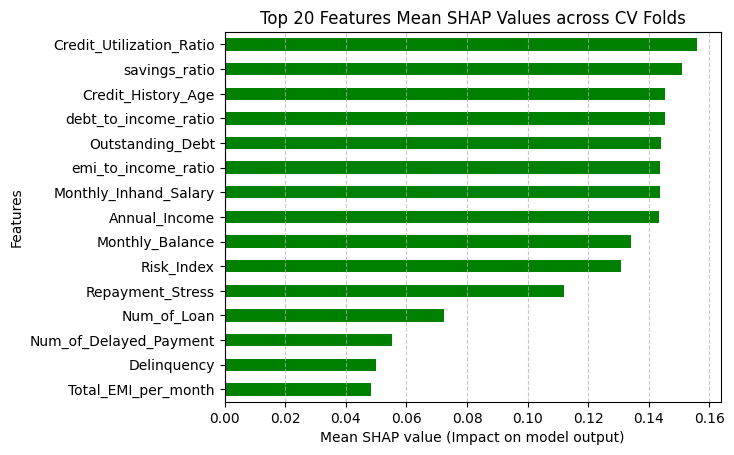

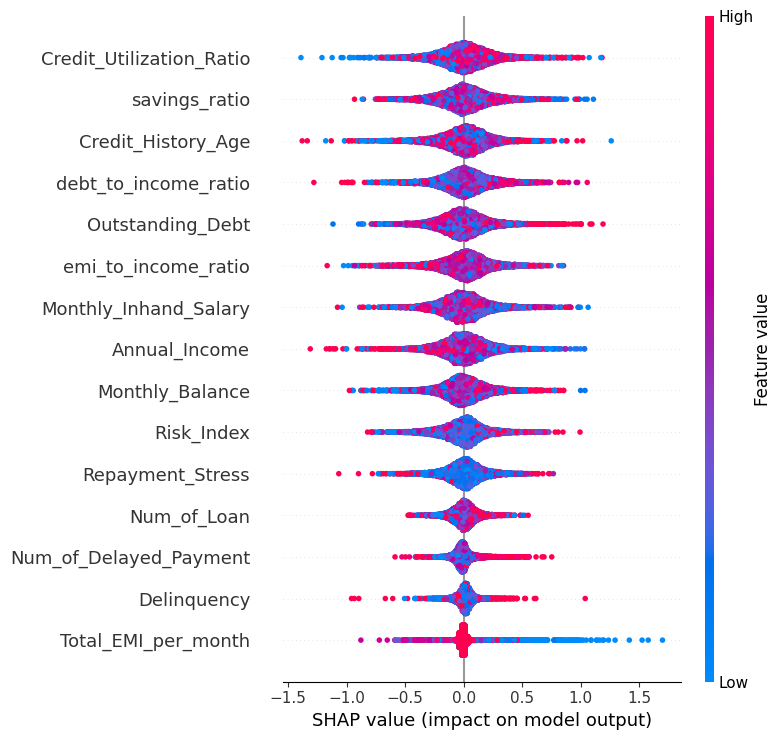

In [43]:
folds = StratifiedKFold(n_splits=7, shuffle=True, random_state=42)
shap_values_list = []

for train_idx, val_idx in folds.split(X,y):

    xgb_m = XGBClassifier(enable_categorical=True, tree_method="hist").fit(X.iloc[train_idx], y.iloc[train_idx])

    explainer = shap.TreeExplainer(xgb_m)
    shap_fold = explainer.shap_values(X.iloc[val_idx])
    shap_values_list.append(shap_fold)

all_shap = np.vstack(shap_values_list)
mean_shap = np.abs(all_shap).mean(axis=0)

feature_importance = pd.Series(mean_shap, index=X.columns).sort_values(ascending=False)

#print("Top Features - Mean Absolute SHAP values:")
#print(feature_importance)

plt.Figure(figsize=(10, 6))
feature_importance.head(20).plot(kind="barh", color="green").invert_yaxis()
plt.title("Top 20 Features Mean SHAP Values across CV Folds")
plt.xlabel("Mean SHAP value (Impact on model output)")
plt.ylabel("Features")
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.show()

shap.summary_plot(all_shap, X.iloc[np.concatenate([v for _, v in folds.split(X,y)])])

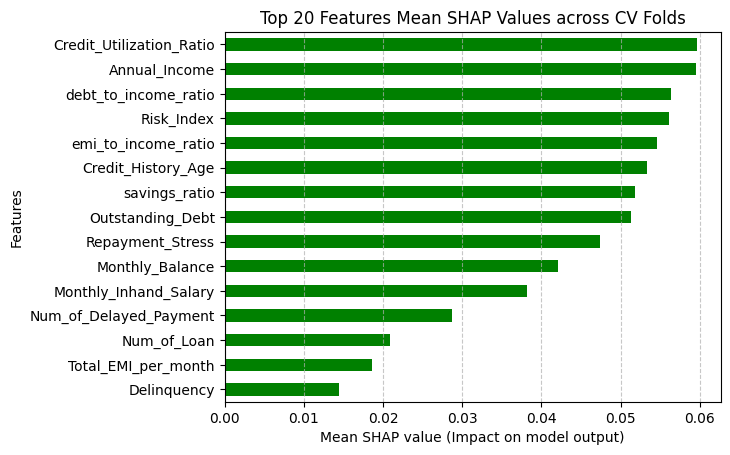

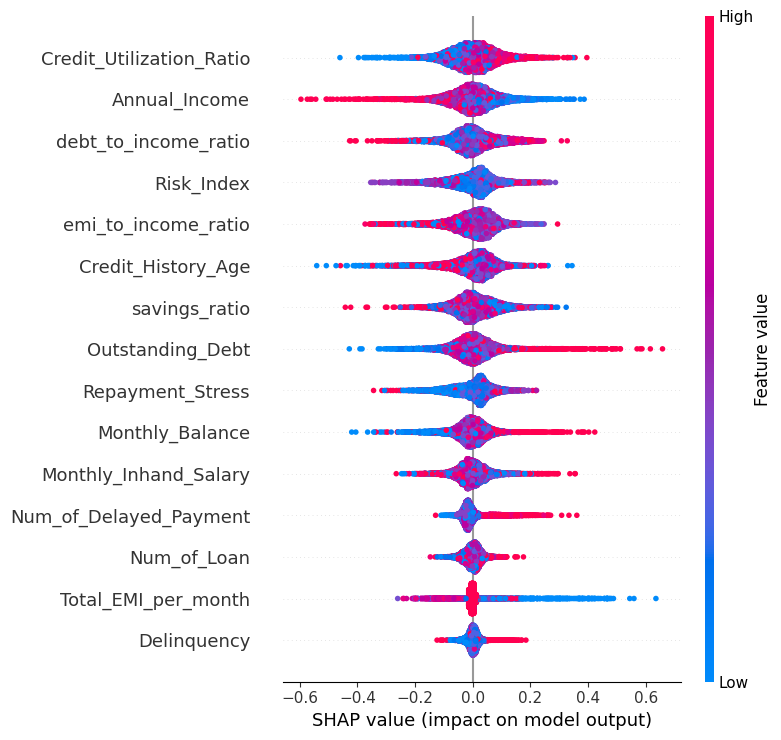

In [44]:
folds = StratifiedKFold(n_splits=7, shuffle=True, random_state=42)
shap_values_list = []

for train_idx, val_idx in folds.split(X,y):

    xgb_m = XGBClassifier(n_estimators=500,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.8,
    #scale_pos_weight=scale_pos_weight,
    colsample_bytree=0.8,
    min_child_weight=5,
    gamma=0.1,
    reg_alpha=0.5,
    enable_categorical=True, 
    tree_method="hist",
    reg_lambda=1.5,
    max_delta_step=1,
    random_state=42).fit(X.iloc[train_idx], y.iloc[train_idx])

    explainer = shap.TreeExplainer(xgb_m)
    shap_fold = explainer.shap_values(X.iloc[val_idx])
    shap_values_list.append(shap_fold)

all_shap = np.vstack(shap_values_list)
mean_shap = np.abs(all_shap).mean(axis=0)

feature_importance = pd.Series(mean_shap, index=X.columns).sort_values(ascending=False)

#print("Top Features - Mean Absolute SHAP values:")
#print(feature_importance)

plt.Figure(figsize=(10, 6))
feature_importance.head(20).plot(kind="barh", color="green").invert_yaxis()
plt.title("Top 20 Features Mean SHAP Values across CV Folds")
plt.xlabel("Mean SHAP value (Impact on model output)")
plt.ylabel("Features")
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.show()

shap.summary_plot(all_shap, X.iloc[np.concatenate([v for _, v in folds.split(X,y)])])